## Formula Generation — Project

Сравнение трёх стратегий подачи знаний о языке формул в LLM.

## Структура проекта

```
project/
├── prompts/
│   ├── __init__.py
│   └── formula.py          # FORMULA_REFERENCE, get_system_prompt(), get_data_prompt()
├── data/
│   └── dataset.json        # схема датасета (поля + типы) — Кинопоиск, 20 полей
├── golden_set/
│   └── golden_set.json     # 59 пар {question, formula, alternatives, category}
├── services/
│   ├── rag_stateful/
│   │   └── main.py         # FastAPI, RAG инициализируется при старте (порт 8001)
│   └── rag_stateless/
│       └── main.py         # FastAPI, RAG строится на каждый запрос (порт 8002)
├── results/                # метрики экспериментов (JSON)
└── project.ipynb           # этот файл
```

## Эксперименты

**LLM:** DeepSeek V3 (`deepseek-chat` via Yandex API)

| # | Стратегия | RAG | Эмбеддеры |
|---|-----------|-----|----------|
| 1 | Full prompt | — | — |
| 2 | Stateful RAG | ✅ (один раз при старте) | bge-m3, multilingual-e5-large, Qodo-Embed-1-1.5B (via vLLM) |
| 3 | Stateless RAG | ✅ (каждый запрос) | лучший из эксп. 2 |

## Метрики

- **prompt_tokens** — токены в промпте
- **completion_tokens** — токены в ответе
- **latency_s** — полное время запроса: retrieval (включая перестройку индекса у stateless) + LLM-генерация
- **exact_match** — точное совпадение с голденсетом или альтернативой (0/1, whitespace-нормализованное)
- **llm_judge_score** — оценка LLM-as-judge (0–10)
- **index_build_ms** — время перестройки индекса внутри retrieval (только stateless; показывает накладные расходы на rebuild)
- **cost_usd** — стоимость запроса (prompt + completion × цена за токен)

## Этап 0 — Инициализация

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from prompts.formula import FORMULA_REFERENCE, get_system_prompt, get_data_prompt, get_rag_system_prompt

print(f'Formula reference: {len(FORMULA_REFERENCE):,} chars')
print(f'System prompt:     {len(get_system_prompt()):,} chars')

Formula reference: 80,552 chars
System prompt:     84,624 chars


In [2]:
import json
from pathlib import Path

# --- Загрузка датасета ---
# Формат data/dataset.json:
# {"fields": [{"name": "...", "data_type": "...", "field_type": "DIMENSION|MEASURE",
#              "description": "...", "formula": "..."}]}
DATASET_PATH = Path('data/dataset.json')

if DATASET_PATH.exists():
    with open(DATASET_PATH) as f:
        dataset = json.load(f)

    def format_fields(fields: list[dict]) -> str:
        lines = []
        for f in fields:
            line = f'[{f["name"]}]: {f["data_type"]} ({f["field_type"]}) — {f["description"]}'
            if f.get('formula'):
                line += f'\n  formula: {f["formula"]}'
            lines.append(line)
        return '\n'.join(lines)

    fields_str = format_fields(dataset['fields'])
    print(f'Loaded {len(dataset["fields"])} fields')
    print(fields_str)
else:
    print('⚠️  data/dataset.json not found — положи файл датасета и перезапусти')

Loaded 20 fields
[Год выпуска]: Integer (DIMENSION) — Год выпуска фильма или начало запуска первого сезона сериала
  formula: GET_ITEM(SPLIT([Годы], "-"), 1)
[Годы]: String (DIMENSION) — Годы, в течение которых выходил сериал
[Дата обновления]: String (DIMENSION) — Дата обновления датасета
[Жанр 1]: String (DIMENSION) — Первый (основной) жанр
  formula: GET_ITEM(SPLIT([Жанры (списком)], ","), 1)
[Жанр 2]: String (DIMENSION) — Второй (второстепенный) жанр
  formula: GET_ITEM(SPLIT([Жанры (списком)], ","), 2)
[Жанр 3]: String (DIMENSION) — Жанр, который указан третьим в списке
  formula: GET_ITEM(SPLIT([Жанры (списком)], ","), 3)
[Жанры (списком)]: String (DIMENSION) — Список жанров
[ИД]: Integer (DIMENSION) — ИД фильма на сайте kinopoisk.ru
[Название]: String (DIMENSION) — Название фильма или сериала
[Продолжительность, мин]: Integer (DIMENSION) — Продолжительность фильма/сериала в минутах
[Ссылка]: Markup (DIMENSION) — Ссылка на сайт с фильмом на kinopoisk.ru. Используй по возможности 

## Этап 1 — Голденсет (59 формул)

59 вопросов + эталонных формул, покрывающих все части языка.

### Покрытие категорий

| Категория | Кол-во | Что проверяем |
|-----------|--------|---------------|
| arithmetic | 5 | `/`, `%`, `ROUND`, `SQRT`, `MAX-MIN` |
| string | 7 | `UPPER`, `LEN`, `LEFT`, `CONTAINS`, `CONCAT+STR`, `TRIM`, `REPLACE` |
| datetime | 7 | `TODAY`, `YEAR`, `WEEK`, `MONTH`, `DATETRUNC`, `TODAY()-N` |
| logic | 8 | `IF/ELSEIF`, `CASE`, `IN`, `ISNULL`, `IFNULL` |
| aggregation | 7 | `AVG`, `COUNTD`, `MAX`, `MIN`, `MEDIAN`, `SUM`, `COUNT_IF` |
| lod | 6 | `FIXED`, `FIXED [dim]`, `BEFORE FILTER BY` |
| window | 5 | `RANK TOTAL/WITHIN`, `SUM TOTAL`, `MAVG`, `RSUM ORDER BY` |
| markup | 4 | `BOLD`, `COLOR`, `MARKUP+BR`, `URL+CONCAT` |
| combined | 10 | `SUM_IF`, `AVG_IF`, string+datetime, logic+agg, lod+logic, string+logic, arithmetic+logic+string, lod+arithmetic+string, markup+logic, string+lod+arithmetic |
| **Итого** | **59** | |

In [3]:
# Структура одной записи голденсета
GOLDEN_EXAMPLE = {
    "id": 1,
    "category": "aggregation",
    "question": "Посчитай суммарную выручку по всем заказам",
    "formula": "SUM([Revenue])",
    "alternatives": ["SUM([Revenue] FIXED)"],
    "notes": "базовый агрегат"
}
print(json.dumps(GOLDEN_EXAMPLE, ensure_ascii=False, indent=2))

{
  "id": 1,
  "category": "aggregation",
  "question": "Посчитай суммарную выручку по всем заказам",
  "formula": "SUM([Revenue])",
  "alternatives": [
    "SUM([Revenue] FIXED)"
  ],
  "notes": "базовый агрегат"
}


In [4]:
GOLDEN_PATH = Path('golden_set/golden_set.json')

if GOLDEN_PATH.exists():
    with open(GOLDEN_PATH) as f:
        golden_set = json.load(f)
    print(f'Golden set: {len(golden_set)} entries')
    from collections import Counter
    for cat, cnt in sorted(Counter(g['category'] for g in golden_set).items()):
        print(f'  {cat}: {cnt}')
else:
    print('⚠️  golden_set.json not found — сгенерируй после получения датасета')

Golden set: 59 entries
  aggregation: 7
  arithmetic: 5
  combined: 10
  datetime: 7
  lod: 6
  logic: 8
  markup: 4
  string: 7
  window: 5


## Этап 2 — Эксперимент 1: Full Prompt

Полный промпт с описанием языка + схема датасета → OpenAI API → формула.

In [ ]:
import re
import time
import os
import httpx
from dotenv import load_dotenv
from openai import OpenAI

PRICE_INPUT  = 0.40 / 1_000_000
PRICE_OUTPUT = 1.60 / 1_000_000
MODEL = 'deepseek-chat'
TEMPERATURE = 0.3

load_dotenv(dotenv_path=Path("../.env"), override=True)  # .env is one level up, override existing env vars

client = OpenAI(
    api_key=os.environ['OPENAI_API_KEY'],
    base_url=os.environ['OPENAI_BASE_URL'],
    http_client=httpx.Client(verify=False),  # disable SSL for corporate proxy
)


def normalize_formula(text: str) -> str:
    """Collapse all whitespace (spaces, tabs, newlines) into single spaces and strip."""
    return re.sub(r'\s+', ' ', text.strip())


def is_exact_match(predicted: str, item: dict) -> int:
    """Return 1 if predicted matches formula or any alternative (whitespace-normalized)."""
    pred_norm = normalize_formula(predicted)
    candidates = [item['formula']] + item.get('alternatives', [])
    return int(any(pred_norm == normalize_formula(c) for c in candidates))


def _strip_comments(text: str) -> str:
    """Remove -- comments (whole lines and inline) from formula text."""
    lines = []
    for line in text.splitlines():
        clean = re.sub(r'\s*--.*$', '', line)
        lines.append(clean)
    return '\n'.join(lines).strip()

def _looks_like_formula(line: str) -> bool:
    """Heuristic: line starts with a field ref, known function, or operator."""
    s = line.strip()
    return bool(
        re.match(r'^\[', s) or
        re.match(r'^[A-Z_]{2,}\(', s) or
        re.match(r'^IF\b|^CASE\b|^WHEN\b|^THEN\b|^ELSE\b|^END\b', s, re.I) or
        re.match(r'^(SUM|AVG|MAX|MIN|COUNT|RANK|RSUM|MAVG|LAG|MARKUP|BOLD|COLOR|URL|CONCAT|STR|ROUND|SQRT|LEFT|UPPER|LEN|TRIM|REPLACE|CONTAINS|ISNULL|IFNULL|YEAR|TODAY|WEEK|MONTH|DATETRUNC)\b', s, re.I)
    )


def extract_formula(text: str) -> str:
    """Extract formula from model response.

    Priority:
    1. First ``` code block — strip -- comments, return non-empty content
    2. Lines that look like a formula (field refs, function calls)
    3. Last non-empty line as fallback
    """
    # 1. Code block
    block = re.search(r'```(?:\w+)?\n?(.*?)```', text, re.DOTALL)
    if block:
        cleaned = _strip_comments(block.group(1))
        if cleaned:
            return cleaned

    # 2. Formula-like lines (consecutive block)
    lines = text.strip().splitlines()
    formula_lines = []
    for line in lines:
        if _looks_like_formula(line):
            formula_lines.append(line.rstrip())
        elif formula_lines and line.strip() == '':
            break

    if formula_lines:
        return _strip_comments('\n'.join(formula_lines))

    # 3. Fallback: last non-empty line
    non_empty = [l.strip() for l in lines if l.strip()]
    return non_empty[-1] if non_empty else ''


def run_formula_request(
    question: str,
    fields: str,
    system_prompt: str,
    current_formula: str = '',
    errors: str = '',
) -> dict:
    """Send one formula generation request, return answer + usage metrics."""
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user',   'content': get_data_prompt(fields, current_formula, errors) + f'\n\n# ЗАДАЧА\n{question}'},
    ]
    t0 = time.perf_counter()
    resp = client.chat.completions.create(model=MODEL, messages=messages, temperature=TEMPERATURE)
    latency = time.perf_counter() - t0
    u = resp.usage
    return {
        'answer':            resp.choices[0].message.content,
        'prompt_tokens':     u.prompt_tokens,
        'completion_tokens': u.completion_tokens,
        'latency_s':         round(latency, 3),
        'cost_usd':          round(u.prompt_tokens * PRICE_INPUT + u.completion_tokens * PRICE_OUTPUT, 6),
    }

In [10]:
# --- Запуск Эксперимента 1 ---
exp1_results = []
system_prompt_full = get_system_prompt()

for item in golden_set:
    r = run_formula_request(item['question'], fields_str, system_prompt_full)
    predicted = extract_formula(r['answer'])
    match = is_exact_match(predicted, item)
    r.update({
        'id': item['id'], 'category': item['category'],
        'question': item['question'], 'expected': item['formula'],
        'predicted': predicted,
        'exact_match': match,
    })
    exp1_results.append(r)

    status = '✅' if match else '❌'
    print(f"[{item['id']:02d}] {status}  {item['question'][:55]}")
    if not match:
        print(f"       expected:  {normalize_formula(item['formula'])}")
        print(f"       predicted: {normalize_formula(predicted)}")

Path('results').mkdir(exist_ok=True)
with open('results/exp1_full_prompt.json', 'w') as f:
    json.dump(exp1_results, f, ensure_ascii=False, indent=2)
print(f"\nExact match: {sum(r['exact_match'] for r in exp1_results)}/{len(exp1_results)}")

[01] ✅  Вычисли продолжительность фильма в часах
[02] ✅  Округли рейтинг до одного знака после запятой
[03] ✅  Найди разброс рейтингов — разницу максимального и миним
[04] ✅  Вычисли квадратный корень из числа голосов
[05] ✅  Определи последнюю цифру года выпуска фильма
[06] ✅  Переведи название фильма в верхний регистр
[07] ✅  Посчитай количество символов в названии фильма
[08] ✅  Возьми первые 20 символов названия фильма
[09] ✅  Проверь, содержит ли список жанров слово «драма»
[10] ✅  Соедини название фильма и год выпуска в формате «Назван
[11] ✅  Убери лишние пробелы по краям поля «Годы»
[12] ✅  Замени запятую на « | » в списке жанров
[13] ✅  Получи текущий год
[14] ✅  Посчитай возраст фильма — сколько лет прошло с момента 
[15] ✅  Получи текущую дату
[16] ✅  Вычисли начало текущего года
[17] ✅  Получи дату семь дней назад
[18] ✅  Определи номер текущей недели в году
[19] ✅  Получи начало текущего месяца
[20] ✅  Классифицируй фильм по рейтингу: «Высокий» (≥8), «Средн
[21] ✅  Определ

## Этап 3 — Эксперимент 2: Stateful RAG

Сервис поднимается один раз, RAG инициализируется при старте (три эмбеддера поочерёдно).

```bash
# Запуск с нужным эмбеддером:
EMBEDDER=bge-m3 uvicorn services.rag_stateful.main:app --port 8001
```

In [11]:
def run_rag_request(question: str, fields: str, service_url: str, alpha: float = 0.5) -> dict:
    """RAG retrieve → build prompt → OpenAI → return result + metrics."""
    # 1. Retrieval
    t0 = time.perf_counter()
    rag_resp = httpx.post(
        f'{service_url}/retrieve',
        json={'query': question, 'k': 6, 'alpha': alpha},
        timeout=120,
    )
    rag_resp.raise_for_status()
    rag_data = rag_resp.json()
    retrieval_latency = time.perf_counter() - t0

    chunks: list[str] = rag_data['chunks']
    titles: list[str] = rag_data.get('titles', [])
    context = '\n\n---\n\n'.join(chunks)

    # 2. Build RAG system prompt — same preamble as Exp 1, retrieved chunks instead of full reference
    rag_system = get_rag_system_prompt(context)

    # 3. LLM call
    messages = [
        {'role': 'system', 'content': rag_system},
        {'role': 'user',   'content': get_data_prompt(fields) + f'\n\n# ЗАДАЧА\n{question}'},
    ]
    t1 = time.perf_counter()
    resp = client.chat.completions.create(model=MODEL, messages=messages, temperature=TEMPERATURE)
    llm_latency = time.perf_counter() - t1

    u = resp.usage
    return {
        'answer':              resp.choices[0].message.content,
        'chunks_retrieved':    len(chunks),
        'retrieved_titles':    titles,
        'prompt_tokens':       u.prompt_tokens,
        'completion_tokens':   u.completion_tokens,
        'retrieval_latency_s': round(retrieval_latency, 3),
        'llm_latency_s':       round(llm_latency, 3),
        'latency_s':           round(retrieval_latency + llm_latency, 3),
        'cost_usd':            round(u.prompt_tokens * PRICE_INPUT + u.completion_tokens * PRICE_OUTPUT, 6),
        'retrieval_scores':    rag_data.get('scores', []),
        # stateless only — time to rebuild the index per request (None for stateful)
        'index_build_ms':      rag_data.get('index_build_ms'),
    }

In [13]:
# --- Запуск Эксперимента 2 (Stateful RAG, эмбеддеры на базе BERT) ---
# Перед каждым прогоном перезапусти сервис с нужным EMBEDDER

STATEFUL_PORT = 8001
STATEFUL_URL  = f'http://localhost:{STATEFUL_PORT}'

# Получаем имя эмбеддера из сервиса
info = httpx.get(f'{STATEFUL_URL}/info').json()
embedder_name = info['embedder']
print(f'Running stateful RAG with embedder: {embedder_name}')

exp2_results = []
for item in golden_set:
    r = run_rag_request(item['question'], fields_str, STATEFUL_URL)
    predicted = extract_formula(r['answer'])
    r.update({
        'id': item['id'], 'category': item['category'],
        'question': item['question'], 'expected': item['formula'],
        'predicted': predicted,
        'exact_match': is_exact_match(predicted, item),
        'embedder': embedder_name,
    })
    exp2_results.append(r)
    print(f"[{item['id']:02d}] {'✅' if r['exact_match'] else '❌'}  {item['question'][:60]}")
    if not r['exact_match']:
        print(f"       expected:  {normalize_formula(item['formula'])}")
        print(f"       predicted: {normalize_formula(predicted)}")
    if r.get('retrieved_titles'):
        print(f"       chunks: {', '.join(r['retrieved_titles'])}")

out_path = f'results/exp2_stateful_{embedder_name.replace("/", "_")}.json'
with open(out_path, 'w') as f:
    json.dump(exp2_results, f, ensure_ascii=False, indent=2)
print(f'\nSaved → {out_path}')
print(f"Exact match: {sum(r['exact_match'] for r in exp2_results)}/{len(exp2_results)}")

Running stateful RAG with embedder: multilingual-e5-large
[01] ✅  Вычисли продолжительность фильма в часах
       chunks: HOUR, DATETRUNC, DATEADD, DATEPART, COUNT (window), DAY
[02] ✅  Округли рейтинг до одного знака после запятой
       chunks: ROUND, RANK (window), CEILING, FLOOR, DATETRUNC, COUNTD
[03] ✅  Найди разброс рейтингов — разницу максимального и минимально
       chunks: MIN, RANK (window), MAX, FIND, DATETRUNC, COUNTD
[04] ✅  Вычисли квадратный корень из числа голосов
       chunks: SQRT, COUNT, COUNT_IF, COUNT (window), COUNTD_IF, DATETRUNC
[05] ✅  Определи последнюю цифру года выпуска фильма
       chunks: YEAR, RIGHT, DATETRUNC, DATEADD, DATEPART, DAY
[06] ✅  Переведи название фильма в верхний регистр
       chunks: UPPER, POWER, LOWER, FIND, RANK (window), ENDSWITH
[07] ✅  Посчитай количество символов в названии фильма
       chunks: LEN, LEFT, RIGHT, COUNT (window), COUNT_IF, COUNTD
[08] ✅  Возьми первые 20 символов названия фильма
       chunks: LEFT, RIGHT, LEN, SP

### Продолжение эксперимента 2 — qodo-1.5b через vLLM + FastAPI

Qodo-Embed не работает через `transformers` (Python 3.13 + MPS segfault).
Решение: vLLM как embedding-бэкенд, stateful RAG сервис как прослойка.

**Шаг 1 — запусти vLLM в терминале 1:**
```bash
source ../.venv/bin/activate
VLLM_HOST_IP=127.0.0.1 vllm serve Qodo/Qodo-Embed-1-1.5B \
    --runner pooling --port 8003 --dtype float16
```

**Шаг 2 — запусти RAG сервис в терминале 2:**
```bash
source ../.venv/bin/activate
cd /Users/kornilovyv/Desktop/learning/otus/llm_dd/project
EMBEDDER=qodo-1.5b VLLM_URL=http://localhost:8003 \
    uvicorn services.rag_stateful.main:app --port 8001
```

Дождись `[stateful] Ready`, затем запускай ячейку ниже.

In [14]:
# --- Запуск Эксперимента 2 (qodo-1.5b через vLLM) ---
# Интерфейс тот же, что для bge-m3 и multilingual-e5-large

STATEFUL_PORT = 8001
STATEFUL_URL  = f'http://localhost:{STATEFUL_PORT}'

info = httpx.get(f'{STATEFUL_URL}/info').json()
embedder_name = info['embedder']
print(f'Running stateful RAG with embedder: {embedder_name}')
print(f'Model: {info["model"]}, chunks: {info["n_chunks"]}, startup: {info["startup_ms"]} ms')

exp2_results = []
for item in golden_set:
    r = run_rag_request(item['question'], fields_str, STATEFUL_URL)
    predicted = extract_formula(r['answer'])
    r.update({
        'id': item['id'], 'category': item['category'],
        'question': item['question'], 'expected': item['formula'],
        'predicted': predicted,
        'exact_match': is_exact_match(predicted, item),
        'embedder': embedder_name,
    })
    exp2_results.append(r)
    print(f"[{item['id']:02d}] {'✅' if r['exact_match'] else '❌'}  {item['question'][:60]}")
    if not r['exact_match']:
        print(f"       expected:  {normalize_formula(item['formula'])}")
        print(f"       predicted: {normalize_formula(predicted)}")
    if r.get('retrieved_titles'):
        print(f"       chunks: {', '.join(r['retrieved_titles'])}")

out_path = f'results/exp2_stateful_{embedder_name.replace("/", "_")}.json'
with open(out_path, 'w') as f:
    json.dump(exp2_results, f, ensure_ascii=False, indent=2)
print(f'\nSaved → {out_path}')
print(f"Exact match: {sum(r['exact_match'] for r in exp2_results)}/{len(exp2_results)}")


Running stateful RAG with embedder: qodo-1.5b
Model: Qodo/Qodo-Embed-1-1.5B, chunks: 199, startup: 292611 ms
[01] ✅  Вычисли продолжительность фильма в часах
       chunks: HOUR, DATEADD, DATETRUNC, DATEPART, DAY, COUNT
[02] ✅  Округли рейтинг до одного знака после запятой
       chunks: ROUND, CEILING, FLOOR, RANK (window), DATETRUNC, COUNTD_APPROX
[03] ✅  Найди разброс рейтингов — разницу максимального и минимально
       chunks: RANK (window), MAX, MIN, Aggregate Functions — Overview, COUNTD, Window Functions — Overview
[04] ✅  Вычисли квадратный корень из числа голосов
       chunks: SQRT, COUNT, COUNT (window), COUNT_IF, COUNTD, FLOOR
[05] ✅  Определи последнюю цифру года выпуска фильма
       chunks: YEAR, RIGHT, DATEPART, DATETRUNC, DAY, DATEADD
[06] ✅  Переведи название фильма в верхний регистр
       chunks: UPPER, LOWER, POWER, RANK (window), DB_CALL_STRING, DB_CALL_AGG_STRING
[07] ✅  Посчитай количество символов в названии фильма
       chunks: LEN, COUNT (window), RIGHT, LE

## Этап 3.5 — Сравнение эмбеддеров (Exp 2)

Запусти после того, как прогнал все три эмбеддера.
Ячейка загружает сохранённые JSON и выбирает лучший эмбеддер по `llm_judge_avg`.

In [15]:
EMBEDDER_NAMES = ['bge-m3', 'multilingual-e5-large', 'qodo-1.5b']

exp2_all: dict[str, list[dict]] = {}
for emb in EMBEDDER_NAMES:
    safe = emb.replace("/", "_")
    # Prefer _judged file (has llm_judge_score); fall back to plain results file
    for suffix in ['_judged', '']:
        p = Path(f'results/exp2_stateful_{safe}{suffix}.json')
        if p.exists():
            with open(p) as f:
                exp2_all[emb] = json.load(f)
            label = '(judged)' if suffix == '_judged' else '(no judge yet)'
            print(f"  {emb}: loaded {len(exp2_all[emb])} results {label}")
            break
    else:
        print(f"  {emb}: ⚠️  not found — запусти Exp 2 с этим эмбеддером")

if exp2_all:
    # Rank by llm_judge_avg if scores are available, otherwise by exact_match
    has_judge = any(
        r.get('llm_judge_score', 0) > 0
        for results in exp2_all.values()
        for r in results
    )
    rank_by = 'llm_judge_avg' if has_judge else 'exact_match_rate'
    if not has_judge:
        print("  ℹ️  Judge scores not available yet — ranking by exact_match.")
        print("     Для оценки по LLM-judge: запусти Этап 5 после каждого Exp 2, затем перезапусти эту ячейку.\n")

    print(f"\n{'Embedder':<30} {'ExactMatch':>10} {'LLMJudge':>9} {'Latency':>9} {'Cost$':>9}")
    print('-' * 72)
    best_emb, best_score = None, -1
    for emb, results in exp2_all.items():
        em   = sum(r['exact_match'] for r in results) / len(results)
        jscores = [r.get('llm_judge_score', 0) for r in results]
        jav  = sum(jscores) / len(jscores)
        lat  = sum(r['latency_s'] for r in results) / len(results)
        cost = sum(r['cost_usd'] for r in results)
        print(f"{emb:<30} {em:>10.2%} {jav:>9.2f} {lat:>9.2f}s {cost:>9.5f}")
        rank_val = jav if has_judge else em
        if rank_val > best_score:
            best_score, best_emb = rank_val, emb

    print(f"\n✅ Best embedder: {best_emb}  ({rank_by}={best_score:.2f})")
    print(f"   Use this for Exp 3: EMBEDDER={best_emb}")

  bge-m3: loaded 59 results (no judge yet)
  multilingual-e5-large: loaded 59 results (no judge yet)
  qodo-1.5b: loaded 59 results (no judge yet)
  ℹ️  Judge scores not available yet — ranking by exact_match.
     Для оценки по LLM-judge: запусти Этап 5 после каждого Exp 2, затем перезапусти эту ячейку.


Embedder                       ExactMatch  LLMJudge   Latency     Cost$
------------------------------------------------------------------------
bge-m3                             81.36%      0.00      6.76s   0.10147
multilingual-e5-large              72.88%      0.00      7.13s   0.09966
qodo-1.5b                          88.14%      0.00      6.51s   0.10062

✅ Best embedder: qodo-1.5b  (exact_match_rate=0.88)
   Use this for Exp 3: EMBEDDER=qodo-1.5b


## Этап 4 — Эксперимент 3: Stateless RAG

RAG строится заново на каждый запрос. Лучший эмбеддер из Эксп. 2.

```bash
EMBEDDER=<best> uvicorn services.rag_stateless.main:app --port 8002
```

In [16]:
STATELESS_PORT = 8002
STATELESS_URL  = f'http://localhost:{STATELESS_PORT}'

info = httpx.get(f'{STATELESS_URL}/info').json()
embedder_name = info['embedder']
print(f'Running stateless RAG with embedder: {embedder_name}')

# Берём 5 вопросов — по одному из каждой основной категории
SAMPLE_IDS = [2, 8, 36, 41, 47]   # arithmetic, string, lod, window, markup
sample = [item for item in golden_set if item['id'] in SAMPLE_IDS]

exp3_results = []
for item in sample:
    r = run_rag_request(item['question'], fields_str, STATELESS_URL)
    predicted = extract_formula(r['answer'])
    r.update({
        'id': item['id'], 'category': item['category'],
        'question': item['question'], 'expected': item['formula'],
        'predicted': predicted,
        'exact_match': is_exact_match(predicted, item),
        'embedder': embedder_name,
    })
    exp3_results.append(r)
    print(f"[{item['id']:02d}] {'✅' if r['exact_match'] else '❌'}  {item['question'][:60]}")
    if not r['exact_match']:
        print(f"       expected:  {normalize_formula(item['formula'])}")
        print(f"       predicted: {normalize_formula(predicted)}")
    print(f"       index_build_ms: {r.get('index_build_ms')} ms, latency: {r['latency_s']} s")

out_path = f'results/exp3_stateless_{embedder_name.replace("/", "_")}.json'
with open(out_path, 'w') as f:
    json.dump(exp3_results, f, ensure_ascii=False, indent=2)
print(f'\nSaved → {out_path}')
print(f"Exact match: {sum(r['exact_match'] for r in exp3_results)}/{len(exp3_results)}")
print(f"Avg index_build_ms: {sum(r['index_build_ms'] for r in exp3_results)/len(exp3_results):.0f} ms")
print(f"Avg latency: {sum(r['latency_s'] for r in exp3_results)/len(exp3_results):.2f} s")


Running stateless RAG with embedder: bge-m3
[02] ✅  Округли рейтинг до одного знака после запятой
       index_build_ms: 25890.7 ms, latency: 29.599 s
[08] ✅  Возьми первые 20 символов названия фильма
       index_build_ms: 24099.9 ms, latency: 27.266 s
[36] ✅  Вычисли средний рейтинг по жанру (Жанр 1), игнорируя другие 
       index_build_ms: 24485.0 ms, latency: 29.503 s
[41] ❌  Присвой каждому фильму ранг по среднему рейтингу среди всех 
       expected:  RANK(AVG([Рейтинг]) TOTAL)
       predicted: RANK([Рейтинг])
       index_build_ms: 25085.1 ms, latency: 35.828 s
[47] ✅  Отобрази название фильма жирным шрифтом
       index_build_ms: 25029.3 ms, latency: 29.742 s

Saved → results/exp3_stateless_bge-m3.json
Exact match: 4/5
Avg index_build_ms: 24918 ms
Avg latency: 30.39 s


## Этап 5 — LLM-as-judge

In [17]:
JUDGE_SYSTEM = """You are an expert evaluator of DataLens formula expressions.
Given a question, one or more correct reference formulas, and a predicted formula,
rate the predicted formula on a scale from 0 to 10:

- 10: Semantically identical to any of the reference formulas (may differ in whitespace/style)
- 7–9: Correct logic, minor style differences
- 4–6: Partially correct (right approach, but contains errors)
- 1–3: Wrong approach, significant errors
- 0: Completely wrong or formula not provided

Respond with JSON only: {"score": <0-10>, "reason": "<one sentence>"}"""


def llm_judge(question: str, expected: str, predicted: str,
              alternatives: list[str] | None = None) -> dict:
    all_variants = [expected] + (alternatives or [])
    if len(all_variants) == 1:
        variants_str = all_variants[0]
        expected_label = f'Expected: {variants_str}'
    else:
        variants_str = '\n'.join(f'  {i+1}. {v}' for i, v in enumerate(all_variants))
        expected_label = f'Expected (any of the following is correct):\n{variants_str}'
    user_msg = f'Question: {question}\n{expected_label}\nPredicted: {predicted}'
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': JUDGE_SYSTEM},
            {'role': 'user',   'content': user_msg},
        ],
        temperature=0,
        response_format={'type': 'json_object'},
    )
    return json.loads(resp.choices[0].message.content)


In [18]:
# Применяем LLM-judge ко всем доступным результатам и выводим сравнение
with open('golden_set/golden_set.json') as f:
    golden_map = {item['id']: item for item in json.load(f)}

RESULT_FILES = [
    ('exp1_full_prompt',               Path('results/exp1_full_prompt.json')),
    ('exp2_stateful_bge-m3',           Path('results/exp2_stateful_bge-m3.json')),
    ('exp2_stateful_multilingual-e5-large', Path('results/exp2_stateful_multilingual-e5-large.json')),
    ('exp2_stateful_qodo-1.5b',        Path('results/exp2_stateful_qodo-1.5b.json')),
    ('exp3_stateless_bge-m3',          Path('results/exp3_stateless_bge-m3.json')),
]

judged_all = {}
for name, path in RESULT_FILES:
    judged_path = path.parent / (path.stem + '_judged.json')
    if judged_path.exists():
        with open(judged_path) as f:
            judged_all[name] = json.load(f)
        print(f"  {name}: loaded cached judge scores")
        continue
    if not path.exists():
        continue
    with open(path) as f:
        results = json.load(f)
    print(f"  {name}: running judge on {len(results)} items…")
    for item in results:
        gs_item = golden_map.get(item['id'], {})
        j = llm_judge(
            item['question'], item['expected'], item['predicted'],
            alternatives=gs_item.get('alternatives', []),
        )
        item['llm_judge_score']  = j.get('score', 0)
        item['llm_judge_reason'] = j.get('reason', '')
    with open(judged_path, 'w') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    judged_all[name] = results

# Сравнительная таблица
print()
print(f"{'Experiment':<42} {'N':>4} {'ExactMatch':>10} {'LLMJudge':>9}")
print('-' * 68)
for name, _ in RESULT_FILES:
    results = judged_all.get(name)
    if results is None:
        continue
    n   = len(results)
    em  = sum(r['exact_match'] for r in results) / n
    jav = sum(r.get('llm_judge_score', 0) for r in results) / n
    print(f"{name:<42} {n:>4} {em:>10.2%} {jav:>9.2f}")


  exp1_full_prompt: running judge on 59 items…
  exp2_stateful_bge-m3: running judge on 59 items…
  exp2_stateful_multilingual-e5-large: running judge on 59 items…
  exp2_stateful_qodo-1.5b: running judge on 59 items…
  exp3_stateless_bge-m3: running judge on 5 items…

Experiment                                    N ExactMatch  LLMJudge
--------------------------------------------------------------------
exp1_full_prompt                             59     88.14%      9.39
exp2_stateful_bge-m3                         59     81.36%      9.19
exp2_stateful_multilingual-e5-large          59     72.88%      8.47
exp2_stateful_qodo-1.5b                      59     88.14%      9.36
exp3_stateless_bge-m3                         5     80.00%      8.60


## Этап 6 — Сводные метрики

In [19]:
import statistics
from collections import defaultdict


def summarize(results: list[dict], name: str) -> dict:
    def avg(key): return round(statistics.mean(r[key] for r in results), 4)

    ibms_values = [r['index_build_ms'] for r in results if r.get('index_build_ms') is not None]

    summary = {
        'experiment':            name,
        'n':                     len(results),
        'exact_match_rate':      round(sum(r['exact_match'] for r in results) / len(results), 4),
        'llm_judge_avg':         avg('llm_judge_score'),
        'prompt_tokens_avg':     avg('prompt_tokens'),
        'completion_tokens_avg': avg('completion_tokens'),
        'latency_s_avg':         avg('latency_s'),
        'cost_usd_total':        round(sum(r['cost_usd'] for r in results), 6),
        'index_build_ms_avg':    round(statistics.mean(ibms_values), 2) if ibms_values else None,
    }

    by_cat = defaultdict(list)
    for r in results:
        by_cat[r['category']].append(r)
    summary['by_category'] = {
        cat: {
            'n': len(items),
            'exact_match_rate': round(sum(i['exact_match'] for i in items) / len(items), 4),
            'llm_judge_avg':    round(statistics.mean(i['llm_judge_score'] for i in items), 4),
        }
        for cat, items in sorted(by_cat.items())
    }
    return summary


# Загружаем все доступные judged-файлы
ALL_RESULT_FILES = [
    ('exp1_full_prompt',                    Path('results/exp1_full_prompt_judged.json')),
    ('exp2_stateful_bge-m3',               Path('results/exp2_stateful_bge-m3_judged.json')),
    ('exp2_stateful_e5-large',             Path('results/exp2_stateful_multilingual-e5-large_judged.json')),
    ('exp2_stateful_qodo-1.5b',            Path('results/exp2_stateful_qodo-1.5b_judged.json')),
    ('exp3_stateless_bge-m3',              Path('results/exp3_stateless_bge-m3_judged.json')),
]

summaries = []
for name, path in ALL_RESULT_FILES:
    if not path.exists():
        # fallback: try without _judged suffix
        plain = path.parent / (path.stem.replace('_judged', '') + '.json')
        if plain.exists():
            with open(plain) as f:
                data = json.load(f)
            # fill missing llm_judge_score with 0
            for r in data:
                r.setdefault('llm_judge_score', 0)
            summaries.append(summarize(data, name))
        # else skip
    else:
        with open(path) as f:
            data = json.load(f)
        summaries.append(summarize(data, name))

with open('results/metrics_summary.json', 'w') as f:
    json.dump(summaries, f, ensure_ascii=False, indent=2)

print(f"{'Experiment':<30} {'N':>4} {'ExactMatch':>10} {'LLMJudge':>9} {'Tokens(in)':>11} {'Latency':>9} {'IdxBuild':>10} {'Cost$':>9}")
print('-' * 97)
for s in summaries:
    ibms = f"{s['index_build_ms_avg']:.0f}ms" if s['index_build_ms_avg'] is not None else '—'
    print(
        f"{s['experiment']:<30} {s['n']:>4} {s['exact_match_rate']:>10.2%} {s['llm_judge_avg']:>9.2f} "
        f"{s['prompt_tokens_avg']:>11.0f} {s['latency_s_avg']:>9.2f}s {ibms:>10} {s['cost_usd_total']:>9.5f}"
    )


Experiment                        N ExactMatch  LLMJudge  Tokens(in)   Latency   IdxBuild     Cost$
-------------------------------------------------------------------------------------------------
exp1_full_prompt                 59     88.14%      9.39       22062      7.90s          —   0.54876
exp2_stateful_bge-m3             59     81.36%      9.19        3003      6.76s          —   0.10147
exp2_stateful_e5-large           59     72.88%      8.47        2876      7.13s          —   0.09966
exp2_stateful_qodo-1.5b          59     88.14%      9.36        2930      6.51s          —   0.10062
exp3_stateless_bge-m3             5     80.00%      8.60        3043     30.39s    24918ms   0.00888


## Этап 7 — Визуализация

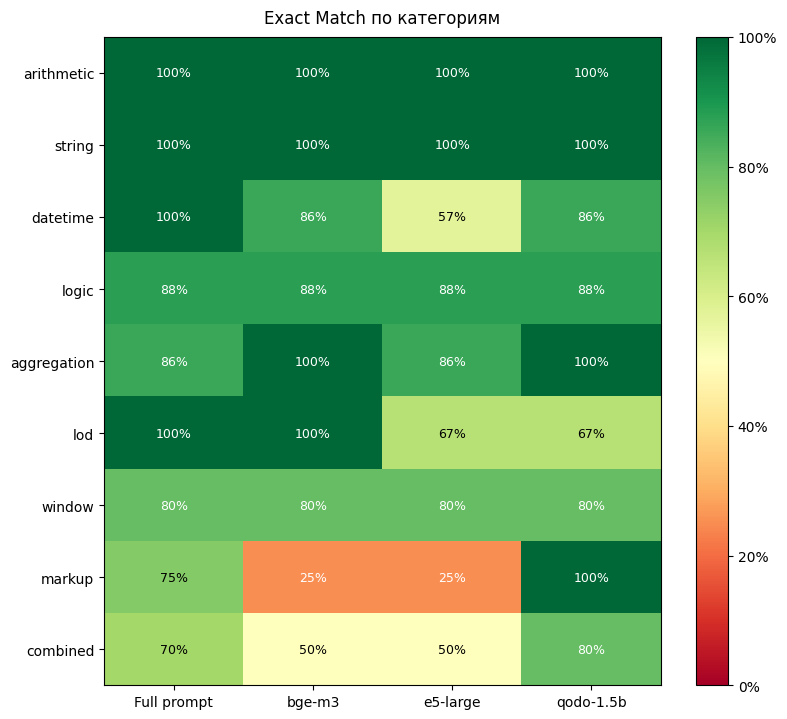

/var/folders/c8/dzcd_fh15mv32gjb6q_ff1gr0000gn/T/ipykernel_69820/2112627773.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_lat, labels=LABELS, patch_artist=True, notch=False)


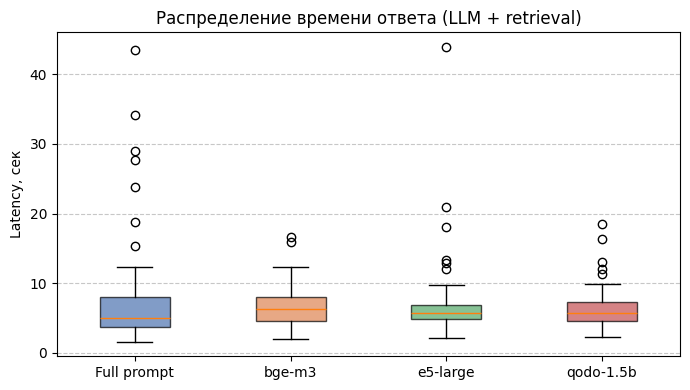

/var/folders/c8/dzcd_fh15mv32gjb6q_ff1gr0000gn/T/ipykernel_69820/2112627773.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_tok, labels=LABELS, patch_artist=True)


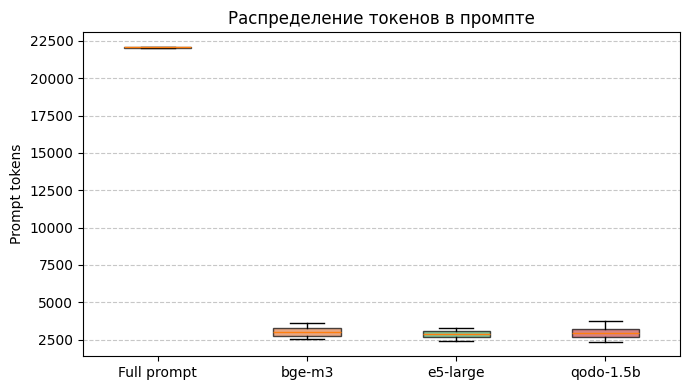

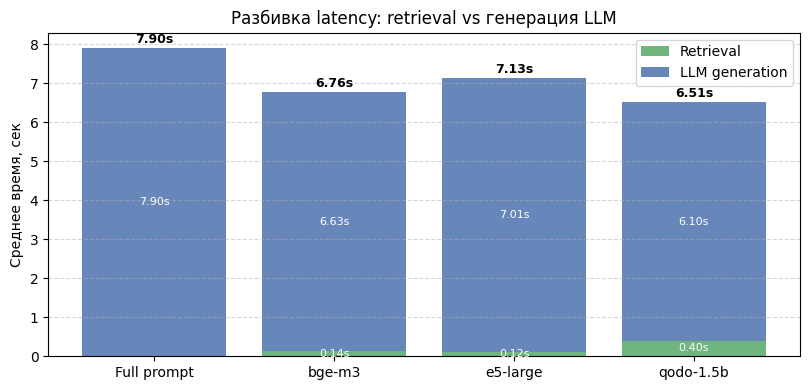

Графики сохранены в results/


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Загрузка всех доступных результатов ──────────────────────────────────────
PLOT_FILES = [
    ('Full prompt',   Path('results/exp1_full_prompt_judged.json')),
    ('bge-m3',        Path('results/exp2_stateful_bge-m3_judged.json')),
    ('e5-large',      Path('results/exp2_stateful_multilingual-e5-large_judged.json')),
    ('qodo-1.5b',     Path('results/exp2_stateful_qodo-1.5b_judged.json')),
]

loaded = {}
for label, path in PLOT_FILES:
    plain = Path(str(path).replace('_judged', ''))
    if path.exists():
        with open(path) as f: loaded[label] = json.load(f)
    elif plain.exists():
        with open(plain) as f: loaded[label] = json.load(f)

CATEGORIES = ['arithmetic', 'string', 'datetime', 'logic',
              'aggregation', 'lod', 'window', 'markup', 'combined']
LABELS = list(loaded.keys())

# ── 1. Heatmap: exact_match по категориям ────────────────────────────────────
cat_em = np.zeros((len(CATEGORIES), len(LABELS)))
for j, label in enumerate(LABELS):
    by_cat = {}
    for r in loaded[label]:
        by_cat.setdefault(r['category'], []).append(r['exact_match'])
    for i, cat in enumerate(CATEGORIES):
        vals = by_cat.get(cat, [])
        cat_em[i, j] = sum(vals) / len(vals) if vals else np.nan

fig, ax = plt.subplots(figsize=(len(LABELS) * 1.8 + 1, len(CATEGORIES) * 0.7 + 1))
im = ax.imshow(cat_em, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, fontsize=10)
ax.set_yticks(range(len(CATEGORIES))); ax.set_yticklabels(CATEGORIES, fontsize=10)
for i in range(len(CATEGORIES)):
    for j in range(len(LABELS)):
        v = cat_em[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                    fontsize=9, color='black' if 0.3 < v < 0.8 else 'white')
plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(xmax=1))
ax.set_title('Exact Match по категориям', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('results/chart_category_heatmap.png', dpi=150)
plt.show()

# ── 2. Box plot: latency по экспериментам ────────────────────────────────────
fig, ax = plt.subplots(figsize=(len(LABELS) * 1.5 + 1, 4))
data_lat = [[r['latency_s'] for r in loaded[l]] for l in LABELS]
bp = ax.boxplot(data_lat, labels=LABELS, patch_artist=True, notch=False)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for patch, color in zip(bp['boxes'], colors[:len(LABELS)]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Latency, сек')
ax.set_title('Распределение времени ответа (LLM + retrieval)')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('results/chart_latency.png', dpi=150)
plt.show()

# ── 3. Box plot: prompt tokens ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(len(LABELS) * 1.5 + 1, 4))
data_tok = [[r['prompt_tokens'] for r in loaded[l]] for l in LABELS]
bp = ax.boxplot(data_tok, labels=LABELS, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(LABELS)]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Prompt tokens')
ax.set_title('Распределение токенов в промпте')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('results/chart_tokens.png', dpi=150)
plt.show()


# ── 4. Stacked bar: retrieval vs LLM latency ─────────────────────────────────
rag_labels = [l for l in LABELS if l != 'Full prompt']
retrieval_means = [
    sum(r.get('retrieval_latency_s', 0) for r in loaded[l]) / len(loaded[l])
    for l in rag_labels
]
llm_means_rag = [
    sum(r.get('llm_latency_s', r['latency_s']) for r in loaded[l]) / len(loaded[l])
    for l in rag_labels
]
# Full prompt: только LLM (retrieval=0)
fp_llm = sum(r['latency_s'] for r in loaded['Full prompt']) / len(loaded['Full prompt'])

all_labels  = ['Full prompt'] + rag_labels
all_ret     = [0] + retrieval_means
all_llm     = [fp_llm] + llm_means_rag

x = np.arange(len(all_labels))
fig, ax = plt.subplots(figsize=(len(all_labels) * 1.8 + 1, 4))
bar_ret = ax.bar(x, all_ret, label='Retrieval', color='#55A868', alpha=0.85)
bar_llm = ax.bar(x, all_llm, bottom=all_ret, label='LLM generation', color='#4C72B0', alpha=0.85)

for xi, (r, l) in enumerate(zip(all_ret, all_llm)):
    total = r + l
    if r > 0:
        ax.text(xi, r / 2,        f'{r:.2f}s', ha='center', va='center', fontsize=8, color='white')
    ax.text(xi, r + l / 2,        f'{l:.2f}s', ha='center', va='center', fontsize=8, color='white')
    ax.text(xi, total + 0.05,     f'{total:.2f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=10)
ax.set_ylabel('Среднее время, сек')
ax.set_title('Разбивка latency: retrieval vs генерация LLM')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('results/chart_latency_breakdown.png', dpi=150)
plt.show()

print("Графики сохранены в results/")


## Этап 8 — Near-miss анализ

Вопросы где `exact_match=0`, но судья поставил ≥7 — семантически верный ответ, не совпавший с эталоном дословно.

In [21]:
NEAR_MISS_THRESHOLD = 7   # judge score ≥ этого значения считается near-miss

PLOT_FILES = [
    ('Full prompt',  Path('results/exp1_full_prompt_judged.json')),
    ('bge-m3',       Path('results/exp2_stateful_bge-m3_judged.json')),
    ('e5-large',     Path('results/exp2_stateful_multilingual-e5-large_judged.json')),
    ('qodo-1.5b',    Path('results/exp2_stateful_qodo-1.5b_judged.json')),
]

loaded = {}
for label, path in PLOT_FILES:
    if path.exists():
        with open(path) as f:
            loaded[label] = json.load(f)

# ── Сводная таблица ───────────────────────────────────────────────────────────
print(f"{'Experiment':<14} {'N':>4} {'ExactMatch':>10} {'Near-miss':>10} {'Practical':>10} {'Hard fail':>10}")
print('-' * 62)
for label, results in loaded.items():
    n          = len(results)
    exact      = sum(r['exact_match'] for r in results)
    near_miss  = sum(1 for r in results
                     if not r['exact_match'] and r.get('llm_judge_score', 0) >= NEAR_MISS_THRESHOLD)
    hard_fail  = n - exact - near_miss
    practical  = (exact + near_miss) / n
    print(f"{label:<14} {n:>4} {exact/n:>10.1%} {near_miss/n:>10.1%} {practical:>10.1%} {hard_fail/n:>10.1%}")

# ── Near-miss детально: вопросы где все модели near-miss или fail ─────────────
print()
print("=== Near-miss детально (exact=0, judge≥7) ===")
for label, results in loaded.items():
    near = [r for r in results
            if not r['exact_match'] and r.get('llm_judge_score', 0) >= NEAR_MISS_THRESHOLD]
    if not near:
        continue
    print(f"\n{label} ({len(near)} near-misses):")
    for r in sorted(near, key=lambda x: -x['llm_judge_score']):
        print(f"  [{r['id']:02d}] score={r['llm_judge_score']}  {r['question'][:55]}")
        print(f"        exp: {normalize_formula(r['expected'])[:65]}")
        print(f"        got: {normalize_formula(r['predicted'])[:65]}")
        print(f"        why: {r.get('llm_judge_reason', '')[:80]}")

# ── Общие hard failures (провалы у всех моделей, judge<7) ────────────────────
if len(loaded) > 1:
    print()
    print("=== Hard failures у всех моделей (judge < 7) ===")
    all_ids = set(r['id'] for r in next(iter(loaded.values())))
    hard_all = []
    for qid in sorted(all_ids):
        scores = {label: next((r for r in res if r['id'] == qid), None)
                  for label, res in loaded.items()}
        if all(
            s is not None and not s['exact_match'] and s.get('llm_judge_score', 0) < NEAR_MISS_THRESHOLD
            for s in scores.values()
        ):
            sample = next(iter(scores.values()))
            avg_score = sum(s.get('llm_judge_score', 0) for s in scores.values()) / len(scores)
            hard_all.append((qid, avg_score, sample['question'], sample['category']))

    for qid, avg_s, q, cat in hard_all:
        print(f"  [{qid:02d}] avg_judge={avg_s:.1f}  [{cat}]  {q[:65]}")


Experiment        N ExactMatch  Near-miss  Practical  Hard fail
--------------------------------------------------------------
Full prompt      59      88.1%       3.4%      91.5%       8.5%
bge-m3           59      81.4%       8.5%      89.8%      10.2%
e5-large         59      72.9%       8.5%      81.4%      18.6%
qodo-1.5b        59      88.1%       5.1%      93.2%       6.8%

=== Near-miss детально (exact=0, judge≥7) ===

Full prompt (2 near-misses):
  [32] score=10  Вычисли медианную продолжительность фильмов
        exp: MEDIAN([Продолжительность, мин])
        got: MEDIAN(IF [Тип] = "Фильм" THEN [Продолжительность, мин] ELSE NULL
        why: The predicted formula is semantically identical to the second reference formula,
  [60] score=10  Сформируй строку «Жанр: X.X» — название первого жанра и
        exp: CONCAT([Жанр 1], ": ", STR(ROUND(AVG([Рейтинг] FIXED [Жанр 1]), 1
        got: CONCAT("Жанр: ", [Жанр 1], ": ", STR(ROUND(AVG([Рейтинг] FIXED [Ж
        why: The predicted fo